# StockBot: Dual-Input LSTM — Sentiment + Price Forecasting
Extends the vanilla LSTM baseline with a **sentiment signal** sourced from daily FinBERT-scored news headlines.
Three fusion strategies are compared — Concatenation, Cross-Attention, and Gating — each merging an independent
price LSTM and a sentiment LSTM before the regression head.
Training follows the same sliding-window protocol (60-day input → 1-day-ahead output) with Adam, MSE loss, and early stopping.

In [1]:
%pip install -q torch numpy scikit-learn matplotlib pandas yfinance

Note: you may need to restart the kernel to use updated packages.


## 0. Dataset Setup
Downloads the CSV from GitHub if not available locally (e.g. on Colab).

In [2]:
import os, urllib.request

CSV_NAME  = 'aapl_daily_sentiment_2021_2025.csv'
RAW_URL   = ('https://raw.githubusercontent.com/franciscomartinez45/'
             'Stock-Forecasting-LSTM/main/data/processed/' + CSV_NAME)
LOCAL_PATHS = [
    f'../data/processed/{CSV_NAME}',
    f'data/processed/{CSV_NAME}',
    CSV_NAME,
]

csv_path = next((p for p in LOCAL_PATHS if os.path.exists(p)), None)
if csv_path is None:
    print('Downloading dataset from GitHub...')
    urllib.request.urlretrieve(RAW_URL, CSV_NAME)
    csv_path = CSV_NAME
    print('Done.')
else:
    print(f'Dataset found locally: {csv_path}')

Dataset found locally: ../data/processed/aapl_daily_sentiment_2021_2025.csv


## 1. Imports & Config

In [3]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from torch.utils.data import Dataset, DataLoader
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
torch.manual_seed(42)

# ── Hyperparameters ────────────────────────────────────────────────────────
TICKER       = 'AAPL'
START_DATE   = '2021-05-01'
END_DATE     = '2025-12-31'
PAST_HISTORY = 60      # days of history per input window
BATCH_SIZE   = 32
EPOCHS       = 100
LR           = 1e-3
PATIENCE     = 15
TRAIN_RATIO  = 0.8
VAL_RATIO    = 0.1

if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
elif torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
else:
    DEVICE = torch.device('cpu')
print(f'Device: {DEVICE}')

Device: mps


## 2. Data — Load & Align Price + Sentiment
Reads the pre-processed CSV containing daily close prices and FinBERT-derived sentiment scores.
Both signals are z-score normalised using **training-set statistics only** to prevent leakage.

In [4]:
df = pd.read_csv(csv_path, parse_dates=['date'])

# Filter to the configured date window
df = df[(df['date'] >= START_DATE) & (df['date'] <= END_DATE)].reset_index(drop=True)

price_col = 'close' if 'close' in df.columns else 'Close'
prices    = df[price_col].values.astype(np.float32)
dates     = df['date'].tolist()

# Derive sentiment: net FinBERT score = avg_positive − avg_negative (range ≈ −1 to 1)
if 'avg_positive' in df.columns and 'avg_negative' in df.columns:
    sentiments = (df['avg_positive'] - df['avg_negative']).values.astype(np.float32)
elif any('sentiment' in c.lower() for c in df.columns):
    sent_col   = next(c for c in df.columns if 'sentiment' in c.lower())
    sentiments = df[sent_col].values.astype(np.float32)
else:
    sentiments = np.zeros(len(prices), dtype=np.float32)

sentiments = np.clip(sentiments, -1, 1)

n         = len(prices)
train_end = int(n * TRAIN_RATIO)
val_end   = int(n * (TRAIN_RATIO + VAL_RATIO))

# Fit scalers on training data only
scaler_prices     = StandardScaler()
scaler_sentiments = StandardScaler()
scaler_prices.fit(prices[:train_end].reshape(-1, 1))
scaler_sentiments.fit(sentiments[:train_end].reshape(-1, 1))

prices_sc     = scaler_prices.transform(prices.reshape(-1, 1)).flatten()
sentiments_sc = scaler_sentiments.transform(sentiments.reshape(-1, 1)).flatten()

print(f'Date range: {dates[0].date()} → {dates[-1].date()}')
print(f'Total: {n} days | Train: {train_end} | Val: {val_end - train_end} | Test: {n - val_end}')
print(f'Price:     ${prices.min():.2f} – ${prices.max():.2f}')
print(f'Sentiment: [{sentiments.min():.3f}, {sentiments.max():.3f}]  (avg_positive − avg_negative)')

Date range: 2021-05-03 → 2025-12-26
Total: 1160 days | Train: 928 | Val: 116 | Test: 116
Price:     $119.67 – $285.66
Sentiment: [-0.933, 0.935]  (avg_positive − avg_negative)


## 3. Dataset & DataLoaders
Each sample consists of a 60-day price window, a 60-day sentiment window, and the next-day price as the regression target.

In [5]:
class SentimentPriceDataset(Dataset):
    def __init__(self, prices_sc, sentiments_sc):
        self.p = torch.tensor(prices_sc,     dtype=torch.float32)
        self.s = torch.tensor(sentiments_sc, dtype=torch.float32)

    def __len__(self):
        return len(self.p) - PAST_HISTORY

    def __getitem__(self, idx):
        p_win = self.p[idx : idx + PAST_HISTORY].unsqueeze(-1)   # (seq, 1)
        s_win = self.s[idx : idx + PAST_HISTORY].unsqueeze(-1)   # (seq, 1)
        target = self.p[idx + PAST_HISTORY]                       # scalar
        return p_win, s_win, target


train_ds = SentimentPriceDataset(prices_sc[:train_end],                     sentiments_sc[:train_end])
val_ds   = SentimentPriceDataset(prices_sc[train_end - PAST_HISTORY:val_end], sentiments_sc[train_end - PAST_HISTORY:val_end])
test_ds  = SentimentPriceDataset(prices_sc[val_end - PAST_HISTORY:],         sentiments_sc[val_end - PAST_HISTORY:])

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

print(f'Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)} samples')

Train: 868 | Val: 116 | Test: 116 samples


## 4. Model Architectures — Three Fusion Strategies
Each architecture encodes price and sentiment independently with an LSTM, then fuses the representations:

1. **Concatenation** — hidden states concatenated → two-layer FC head.
2. **Cross-Attention** — price queries attend over the full sentiment sequence before the FC head.
3. **Gating** — a learned sigmoid gate controls how much sentiment modulates the price representation.

In [6]:
# ── Strategy 1: Concatenation ──────────────────────────────────────────────
class DualInputConcat(nn.Module):
    def __init__(self, price_hidden=64, sentiment_hidden=32, fusion_dim=64, dropout=0.1):
        super().__init__()
        self.price_lstm     = nn.LSTM(1, price_hidden,     num_layers=1, batch_first=True)
        self.sentiment_lstm = nn.LSTM(1, sentiment_hidden, num_layers=1, batch_first=True)
        self.fusion = nn.Sequential(
            nn.Linear(price_hidden + sentiment_hidden, fusion_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(fusion_dim, 1),
        )

    def forward(self, prices, sentiments):
        _, (h_p, _) = self.price_lstm(prices)
        _, (h_s, _) = self.sentiment_lstm(sentiments)
        return self.fusion(torch.cat([h_p[-1], h_s[-1]], dim=-1)).squeeze(-1)


# ── Strategy 2: Cross-Attention ────────────────────────────────────────────
class DualInputAttention(nn.Module):
    def __init__(self, hidden_dim=64, num_heads=4, dropout=0.1):
        super().__init__()
        self.price_lstm     = nn.LSTM(1, hidden_dim, num_layers=1, batch_first=True)
        self.sentiment_lstm = nn.LSTM(1, hidden_dim, num_layers=1, batch_first=True)
        self.cross_attn = nn.MultiheadAttention(
            embed_dim=hidden_dim, num_heads=num_heads, batch_first=True, dropout=dropout
        )
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim, 32), nn.ReLU(), nn.Dropout(dropout), nn.Linear(32, 1)
        )

    def forward(self, prices, sentiments):
        price_enc, _     = self.price_lstm(prices)
        sentiment_enc, _ = self.sentiment_lstm(sentiments)
        attn_out, _ = self.cross_attn(
            price_enc[:, -1:, :], sentiment_enc, sentiment_enc
        )
        return self.fc(attn_out[:, 0, :]).squeeze(-1)


# ── Strategy 3: Gating ─────────────────────────────────────────────────────
class DualInputGating(nn.Module):
    def __init__(self, hidden_dim=64, dropout=0.1):
        super().__init__()
        self.price_lstm     = nn.LSTM(1, hidden_dim, num_layers=1, batch_first=True)
        self.sentiment_lstm = nn.LSTM(1, hidden_dim, num_layers=1, batch_first=True)
        self.gate_fc  = nn.Linear(2 * hidden_dim, hidden_dim)
        self.merge_fc = nn.Linear(2 * hidden_dim, hidden_dim)
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim, 32), nn.ReLU(), nn.Dropout(dropout), nn.Linear(32, 1)
        )

    def forward(self, prices, sentiments):
        _, (h_p, _) = self.price_lstm(prices)
        _, (h_s, _) = self.sentiment_lstm(sentiments)
        cat = torch.cat([h_p[-1], h_s[-1]], dim=-1)
        gate  = torch.sigmoid(self.gate_fc(cat))
        merge = torch.tanh(self.merge_fc(cat))
        return self.fc(gate * merge).squeeze(-1)


print('Model architectures defined: Concat, Attention, Gating')

Model architectures defined: Concat, Attention, Gating


## 5. Training
Each model is trained with Adam + MSE loss and early stopping on validation loss.

In [7]:
def train_model(model, train_loader, val_loader, epochs=EPOCHS, lr=LR, patience=PATIENCE):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    best_val, p_count = float('inf'), 0
    tr_losses, vl_losses = [], []

    for epoch in range(1, epochs + 1):
        model.train()
        tr = 0.0
        for p, s, y in train_loader:
            p, s, y = p.to(DEVICE), s.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(p, s), y)
            loss.backward()
            optimizer.step()
            tr += loss.item()

        model.eval()
        vl = 0.0
        with torch.no_grad():
            for p, s, y in val_loader:
                vl += criterion(model(p.to(DEVICE), s.to(DEVICE)), y.to(DEVICE)).item()

        tr_losses.append(tr / len(train_loader))
        vl_losses.append(vl / max(len(val_loader), 1))

        if vl_losses[-1] < best_val:
            best_val, p_count = vl_losses[-1], 0
        else:
            p_count += 1
            if p_count >= patience:
                print(f'  Early stop at epoch {epoch}')
                break

        if epoch % 10 == 0:
            print(f'  Epoch {epoch:3d} | Train {tr_losses[-1]:.5f} | Val {vl_losses[-1]:.5f}')

    return tr_losses, vl_losses


os.makedirs('plots', exist_ok=True)

model_concat = DualInputConcat().to(DEVICE)
model_attn   = DualInputAttention().to(DEVICE)
model_gating = DualInputGating().to(DEVICE)

print('Training Concatenation...')
tr_concat, vl_concat = train_model(model_concat, train_loader, val_loader)

print('\nTraining Cross-Attention...')
tr_attn, vl_attn = train_model(model_attn, train_loader, val_loader)

print('\nTraining Gating...')
tr_gating, vl_gating = train_model(model_gating, train_loader, val_loader)

Training Concatenation...


  Epoch  10 | Train 0.02107 | Val 0.05493


  Epoch  20 | Train 0.01684 | Val 0.04158


  Epoch  30 | Train 0.01505 | Val 0.03373


  Epoch  40 | Train 0.01545 | Val 0.03223


...

  Epoch  40 | Train 0.01975 | Val 0.03768


  Epoch  50 | Train 0.01848 | Val 0.02797


  Epoch  60 | Train 0.01675 | Val 0.02632


  Epoch  70 | Train 0.01771 | Val 0.03033


  Early stop at epoch 75


## 6. Training Curves
Training and validation MSE loss for all three fusion strategies.

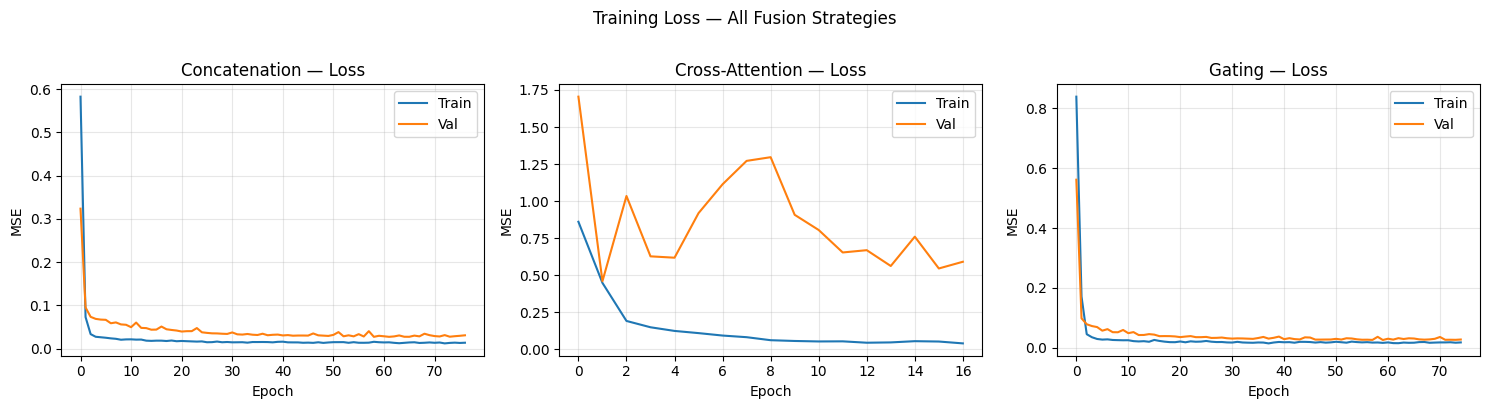

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, tr, vl) in zip(axes, [
    ('Concatenation',   tr_concat, vl_concat),
    ('Cross-Attention', tr_attn,   vl_attn),
    ('Gating',          tr_gating, vl_gating),
]):
    ax.plot(tr, label='Train')
    ax.plot(vl, label='Val')
    ax.set_title(f'{name} — Loss')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Training Loss — All Fusion Strategies', y=1.01)
plt.tight_layout()
plt.savefig('plots/dual_training_loss.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. One-Day-Ahead Forecasting
At each test step the model receives the preceding 60 actual trading days (price + sentiment) and predicts the next day's price.
Inference matches training exactly — no autoregressive feedback.

RMSE — Concat:     $3.55
RMSE — Attention:  $22.61
RMSE — Gating:     $6.65


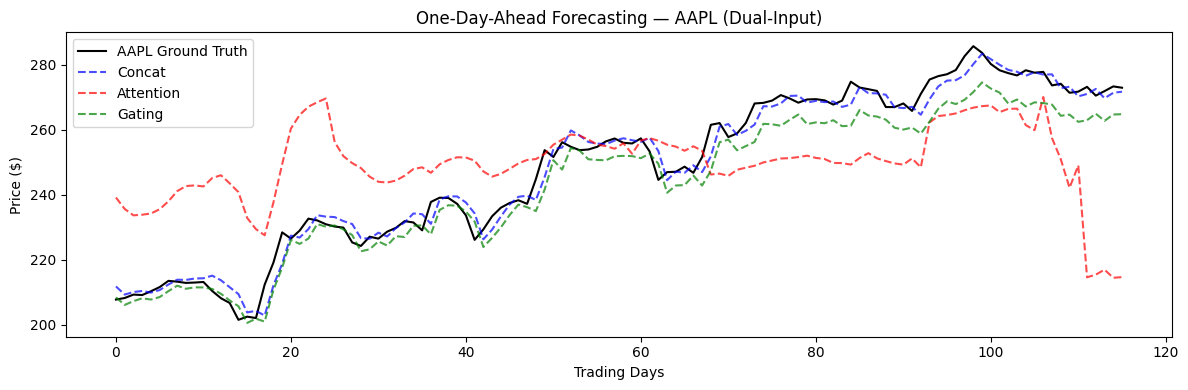

In [9]:
@torch.no_grad()
def sliding_window_forecast(model, n_steps, offset):
    """Predict n_steps days starting from offset using actual history windows."""
    model.eval()
    preds = []
    for i in range(n_steps):
        start = offset - PAST_HISTORY + i
        p_win = torch.tensor(prices_sc[start : start + PAST_HISTORY],
                             dtype=torch.float32).view(1, PAST_HISTORY, 1).to(DEVICE)
        s_win = torch.tensor(sentiments_sc[start : start + PAST_HISTORY],
                             dtype=torch.float32).view(1, PAST_HISTORY, 1).to(DEVICE)
        preds.append(model(p_win, s_win).item())
    return np.array(preds)


n_test     = n - val_end
gt_sc      = prices_sc[val_end:]
test_dates = dates[val_end:]

inv = lambda x: scaler_prices.inverse_transform(x.reshape(-1, 1)).flatten()
actual = inv(gt_sc)

preds_concat = inv(sliding_window_forecast(model_concat, n_test, val_end))
preds_attn   = inv(sliding_window_forecast(model_attn,   n_test, val_end))
preds_gating = inv(sliding_window_forecast(model_gating, n_test, val_end))

rmse = lambda p: np.sqrt(np.mean((p - actual) ** 2))
print(f'RMSE — Concat:     ${rmse(preds_concat):.2f}')
print(f'RMSE — Attention:  ${rmse(preds_attn):.2f}')
print(f'RMSE — Gating:     ${rmse(preds_gating):.2f}')

plt.figure(figsize=(12, 4))
plt.plot(actual,       color='black',  label=f'{TICKER} Ground Truth', linewidth=1.5)
plt.plot(preds_concat, color='blue',   label='Concat',     linestyle='--', alpha=0.7)
plt.plot(preds_attn,   color='red',    label='Attention',  linestyle='--', alpha=0.7)
plt.plot(preds_gating, color='green',  label='Gating',     linestyle='--', alpha=0.7)
plt.title(f'One-Day-Ahead Forecasting — {TICKER} (Dual-Input)')
plt.xlabel('Trading Days'); plt.ylabel('Price ($)'); plt.legend()
plt.tight_layout()
plt.savefig(f'plots/{TICKER}_dual_forecast.png', dpi=150)
plt.show()

## 8. Prediction Error
Relative percentage error of each fusion strategy against the ground truth.

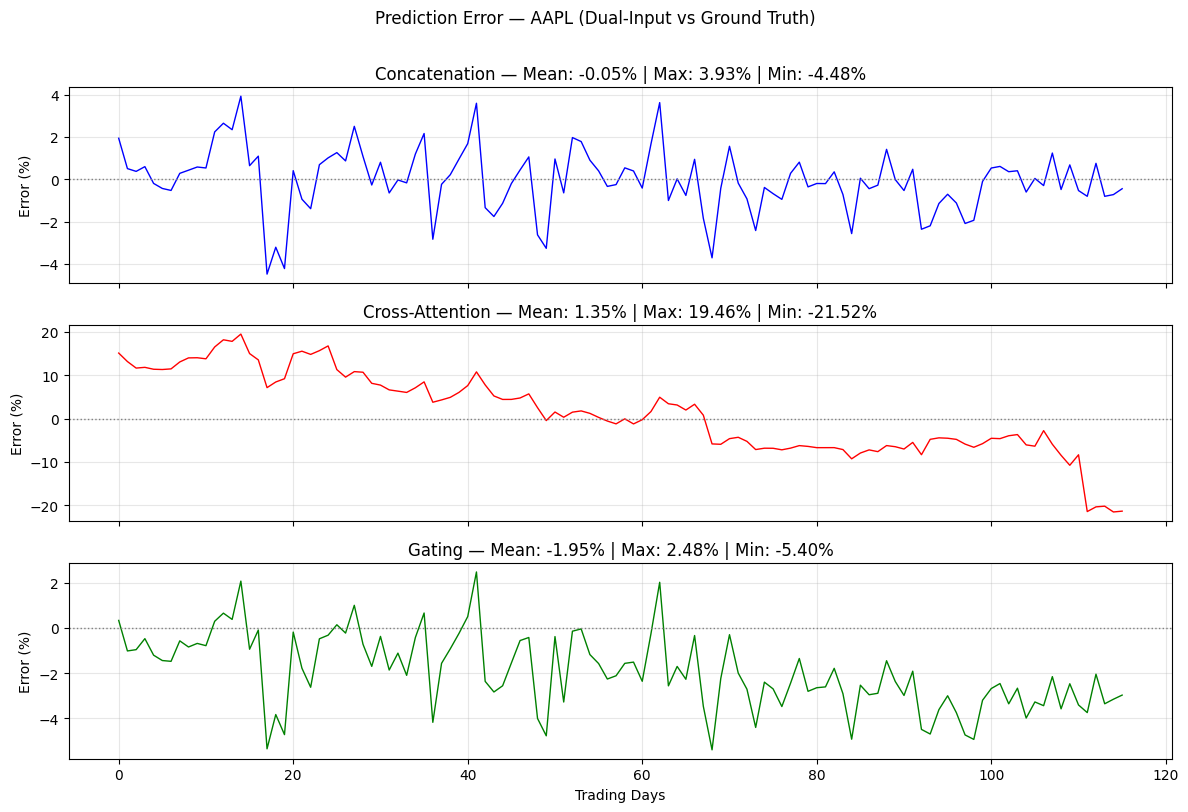

In [10]:
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

for ax, (name, preds, color) in zip(axes, [
    ('Concatenation',   preds_concat, 'blue'),
    ('Cross-Attention', preds_attn,   'red'),
    ('Gating',          preds_gating, 'green'),
]):
    pct = (preds - actual) / actual * 100
    ax.plot(pct, color=color, linewidth=1)
    ax.axhline(0, color='gray', linestyle=':', linewidth=1)
    ax.set_ylabel('Error (%)')
    ax.set_title(f'{name} — Mean: {pct.mean():.2f}% | Max: {pct.max():.2f}% | Min: {pct.min():.2f}%')
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Trading Days')
plt.suptitle(f'Prediction Error — {TICKER} (Dual-Input vs Ground Truth)', y=1.01)
plt.tight_layout()
plt.savefig(f'plots/{TICKER}_dual_prediction_error.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. StockBot Portfolio Strategy
Uses the same algorithm as the baseline: δᵢ = sign(cᵢ₊₁ − cᵢ), Δᵢ = δᵢ₊₁ − δᵢ.
Buy when Δᵢ = +2 (predicted local minimum), sell when Δᵢ = −2 (predicted local maximum).
Starting capital: $100.

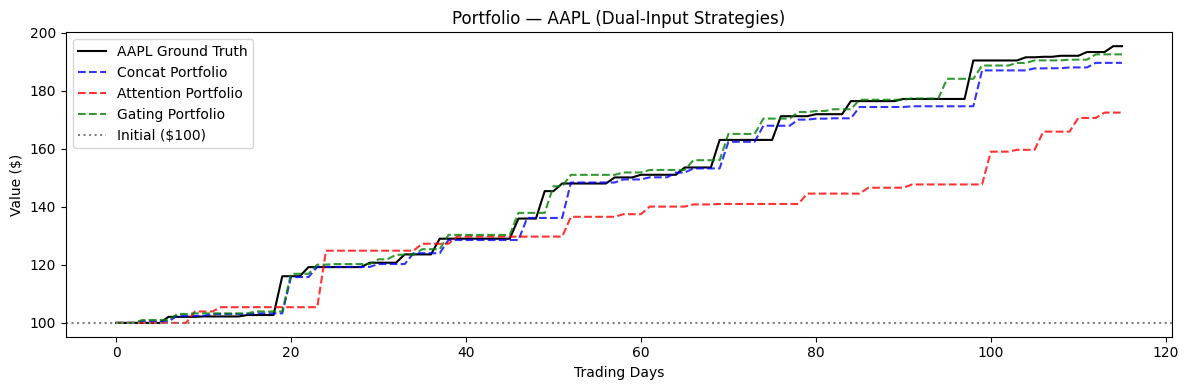

Ground truth portfolio:  $195.40
Concat portfolio:        $189.65
Attention portfolio:     $172.50
Gating portfolio:        $192.58


In [11]:
def stockbot_portfolio(prices, capital=100.0):
    delta = np.sign(np.diff(prices)).astype(int)
    Delta = np.diff(delta)
    held, buy_price, cur = False, 0.0, capital
    portfolio = [cur]
    for i, d in enumerate(Delta):
        sig_price = prices[i + 1]
        if d == 2 and not held:
            held, buy_price = True, sig_price
        elif d == -2 and held:
            held = False
            cur *= sig_price / buy_price
        portfolio.append(cur)
    portfolio.append(cur)
    return np.array(portfolio)


port_gt     = stockbot_portfolio(actual)
port_concat = stockbot_portfolio(preds_concat)
port_attn   = stockbot_portfolio(preds_attn)
port_gating = stockbot_portfolio(preds_gating)

plt.figure(figsize=(12, 4))
plt.plot(port_gt,     color='black', label=f'{TICKER} Ground Truth',  linewidth=1.5)
plt.plot(port_concat, color='blue',  label='Concat Portfolio',   linestyle='--', alpha=0.8)
plt.plot(port_attn,   color='red',   label='Attention Portfolio', linestyle='--', alpha=0.8)
plt.plot(port_gating, color='green', label='Gating Portfolio',   linestyle='--', alpha=0.8)
plt.axhline(100, color='gray', linestyle=':', label='Initial ($100)')
plt.ticklabel_format(useOffset=False, style='plain')
plt.title(f'Portfolio — {TICKER} (Dual-Input Strategies)')
plt.xlabel('Trading Days'); plt.ylabel('Value ($)'); plt.legend()
plt.tight_layout()
plt.savefig(f'plots/{TICKER}_dual_portfolio.png', dpi=150)
plt.show()

print(f'Ground truth portfolio:  ${port_gt[-1]:.2f}')
print(f'Concat portfolio:        ${port_concat[-1]:.2f}')
print(f'Attention portfolio:     ${port_attn[-1]:.2f}')
print(f'Gating portfolio:        ${port_gating[-1]:.2f}')

## 10. Test-Set Metrics Summary
Final RMSE, MAE, and MAPE for each fusion strategy on the held-out test set.

In [12]:
def compute_metrics(preds, actual):
    rmse = np.sqrt(np.mean((preds - actual) ** 2))
    mae  = np.mean(np.abs(preds - actual))
    mape = np.mean(np.abs((preds - actual) / actual)) * 100
    return rmse, mae, mape


print('=' * 60)
print(f'  {"Model":<22} {"RMSE":>8} {"MAE":>8} {"MAPE":>8}')
print('=' * 60)
for name, preds in [
    ('Concatenation',   preds_concat),
    ('Cross-Attention', preds_attn),
    ('Gating',          preds_gating),
]:
    r, m, mp = compute_metrics(preds, actual)
    print(f'  {name:<22} ${r:>6.2f}  ${m:>6.2f}  {mp:>6.2f}%')
print('=' * 60)

  Model                      RMSE      MAE     MAPE
  Concatenation          $  3.55  $  2.67    1.10%
  Cross-Attention        $ 22.61  $ 19.01    7.85%
  Gating                 $  6.65  $  5.49    2.14%
